# Load Data

In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Heart_disease_cleveland.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [7]:
df.shape

(303, 14)

In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Remove Duplicates

Duplicate records were removed to avoid bias.

In [11]:
df.duplicated().sum()
df = df.drop_duplicates()

df.shape


(303, 14)

# Save Clean CSV

In [12]:
# Save cleaned dataset
df.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


# Fix Column Names

This avoids coding errors later.

In [13]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

# Handle Missing Values

In [14]:
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Case A: < 5% missing → Impute
Case B: > 40% missing → Consider dropping column
Case C: Medical dataset → NEVER drop rows blindly

In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])


# Handle Outliers

In [16]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]


# Encode Categorical Features

In [17]:
df = pd.get_dummies(df, drop_first=True)


# Check Class Distribution

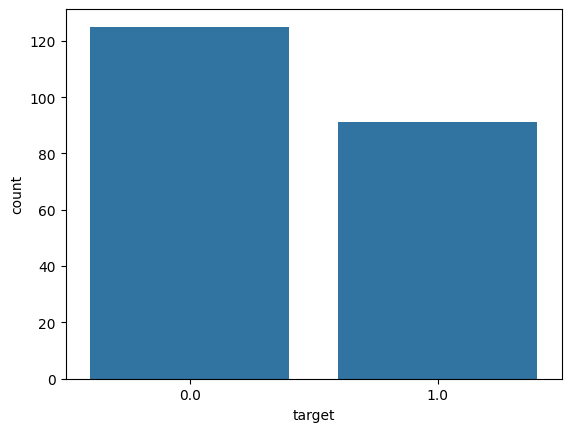

In [18]:
df['target'].value_counts()
df['target'].value_counts(normalize=True)

sns.countplot(x='target', data=df)
plt.show()


# Correlation Analysis

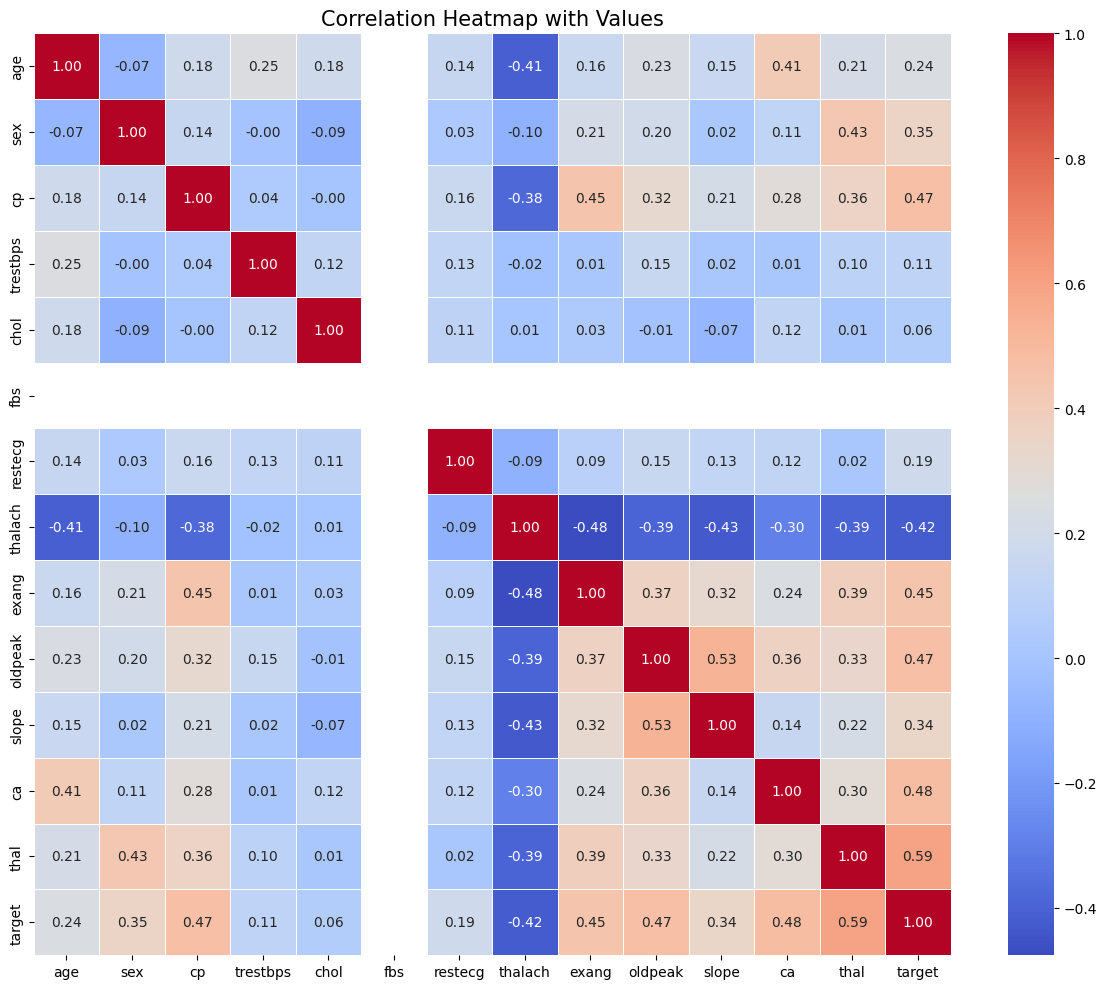

In [19]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap with Values", fontsize=15)
plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Target Variable Analysis

target
0.0    125
1.0     91
Name: count, dtype: int64
target
0.0    0.578704
1.0    0.421296
Name: proportion, dtype: float64


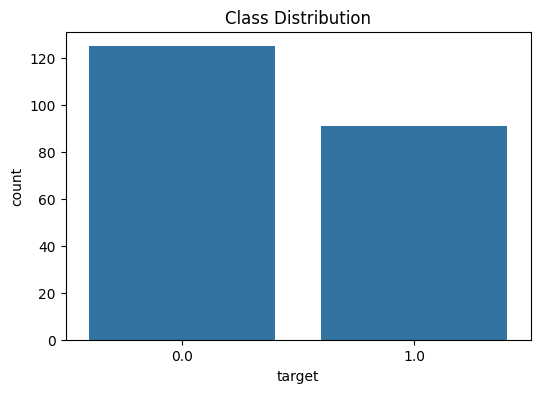

In [20]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()


# Separate Numerical & Categorical Columns

In [21]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numerical Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')
Categorical Columns: Index([], dtype='str')


# Univariate Analysis (Numerical Features)

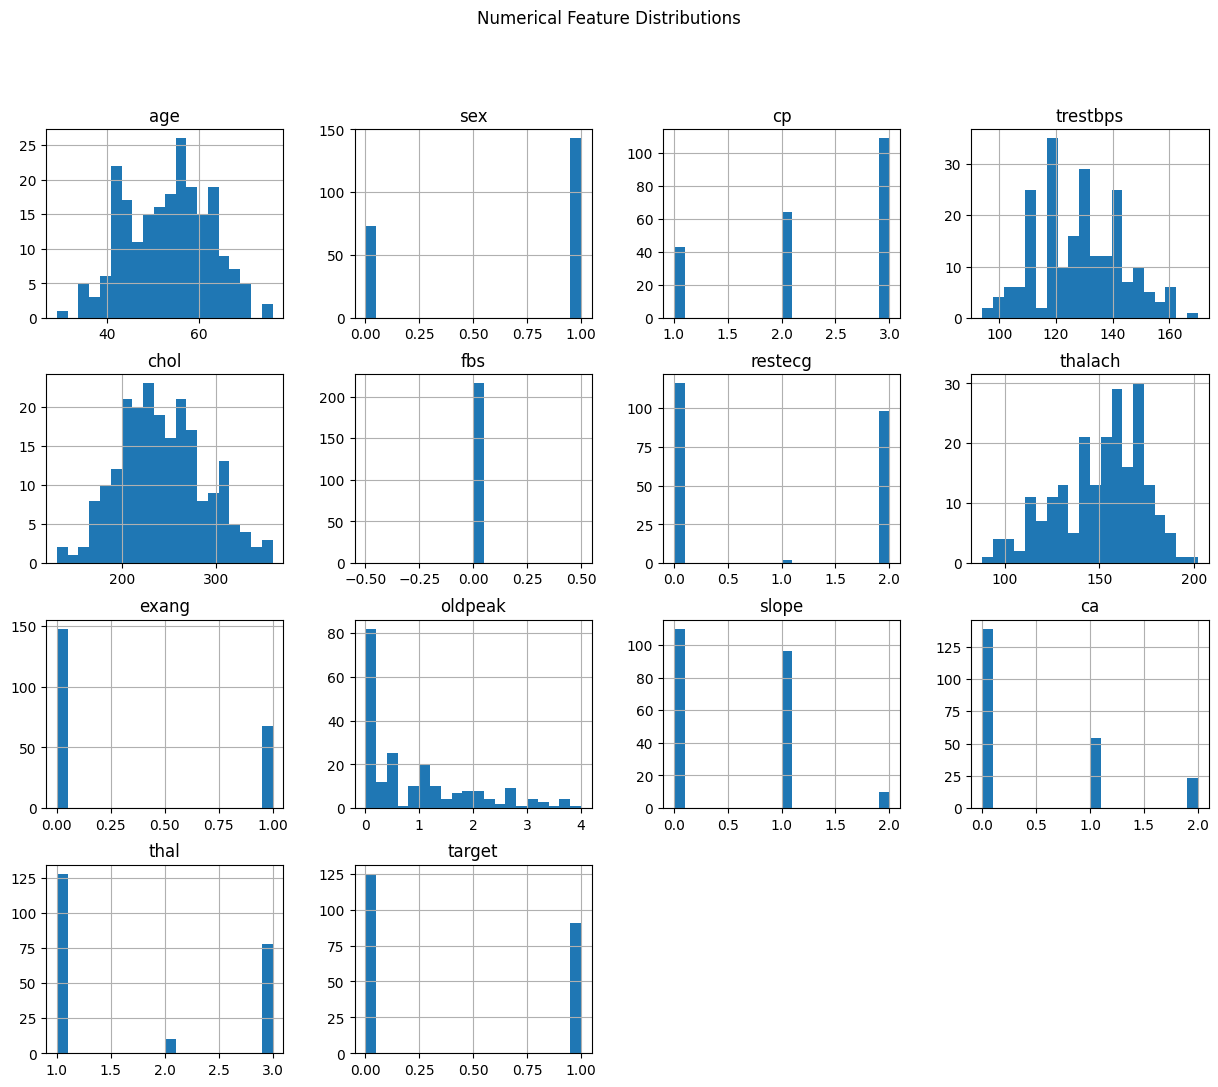

In [22]:
df[numeric_cols].hist(figsize=(15,12), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()


# Boxplot for Outlier Detection

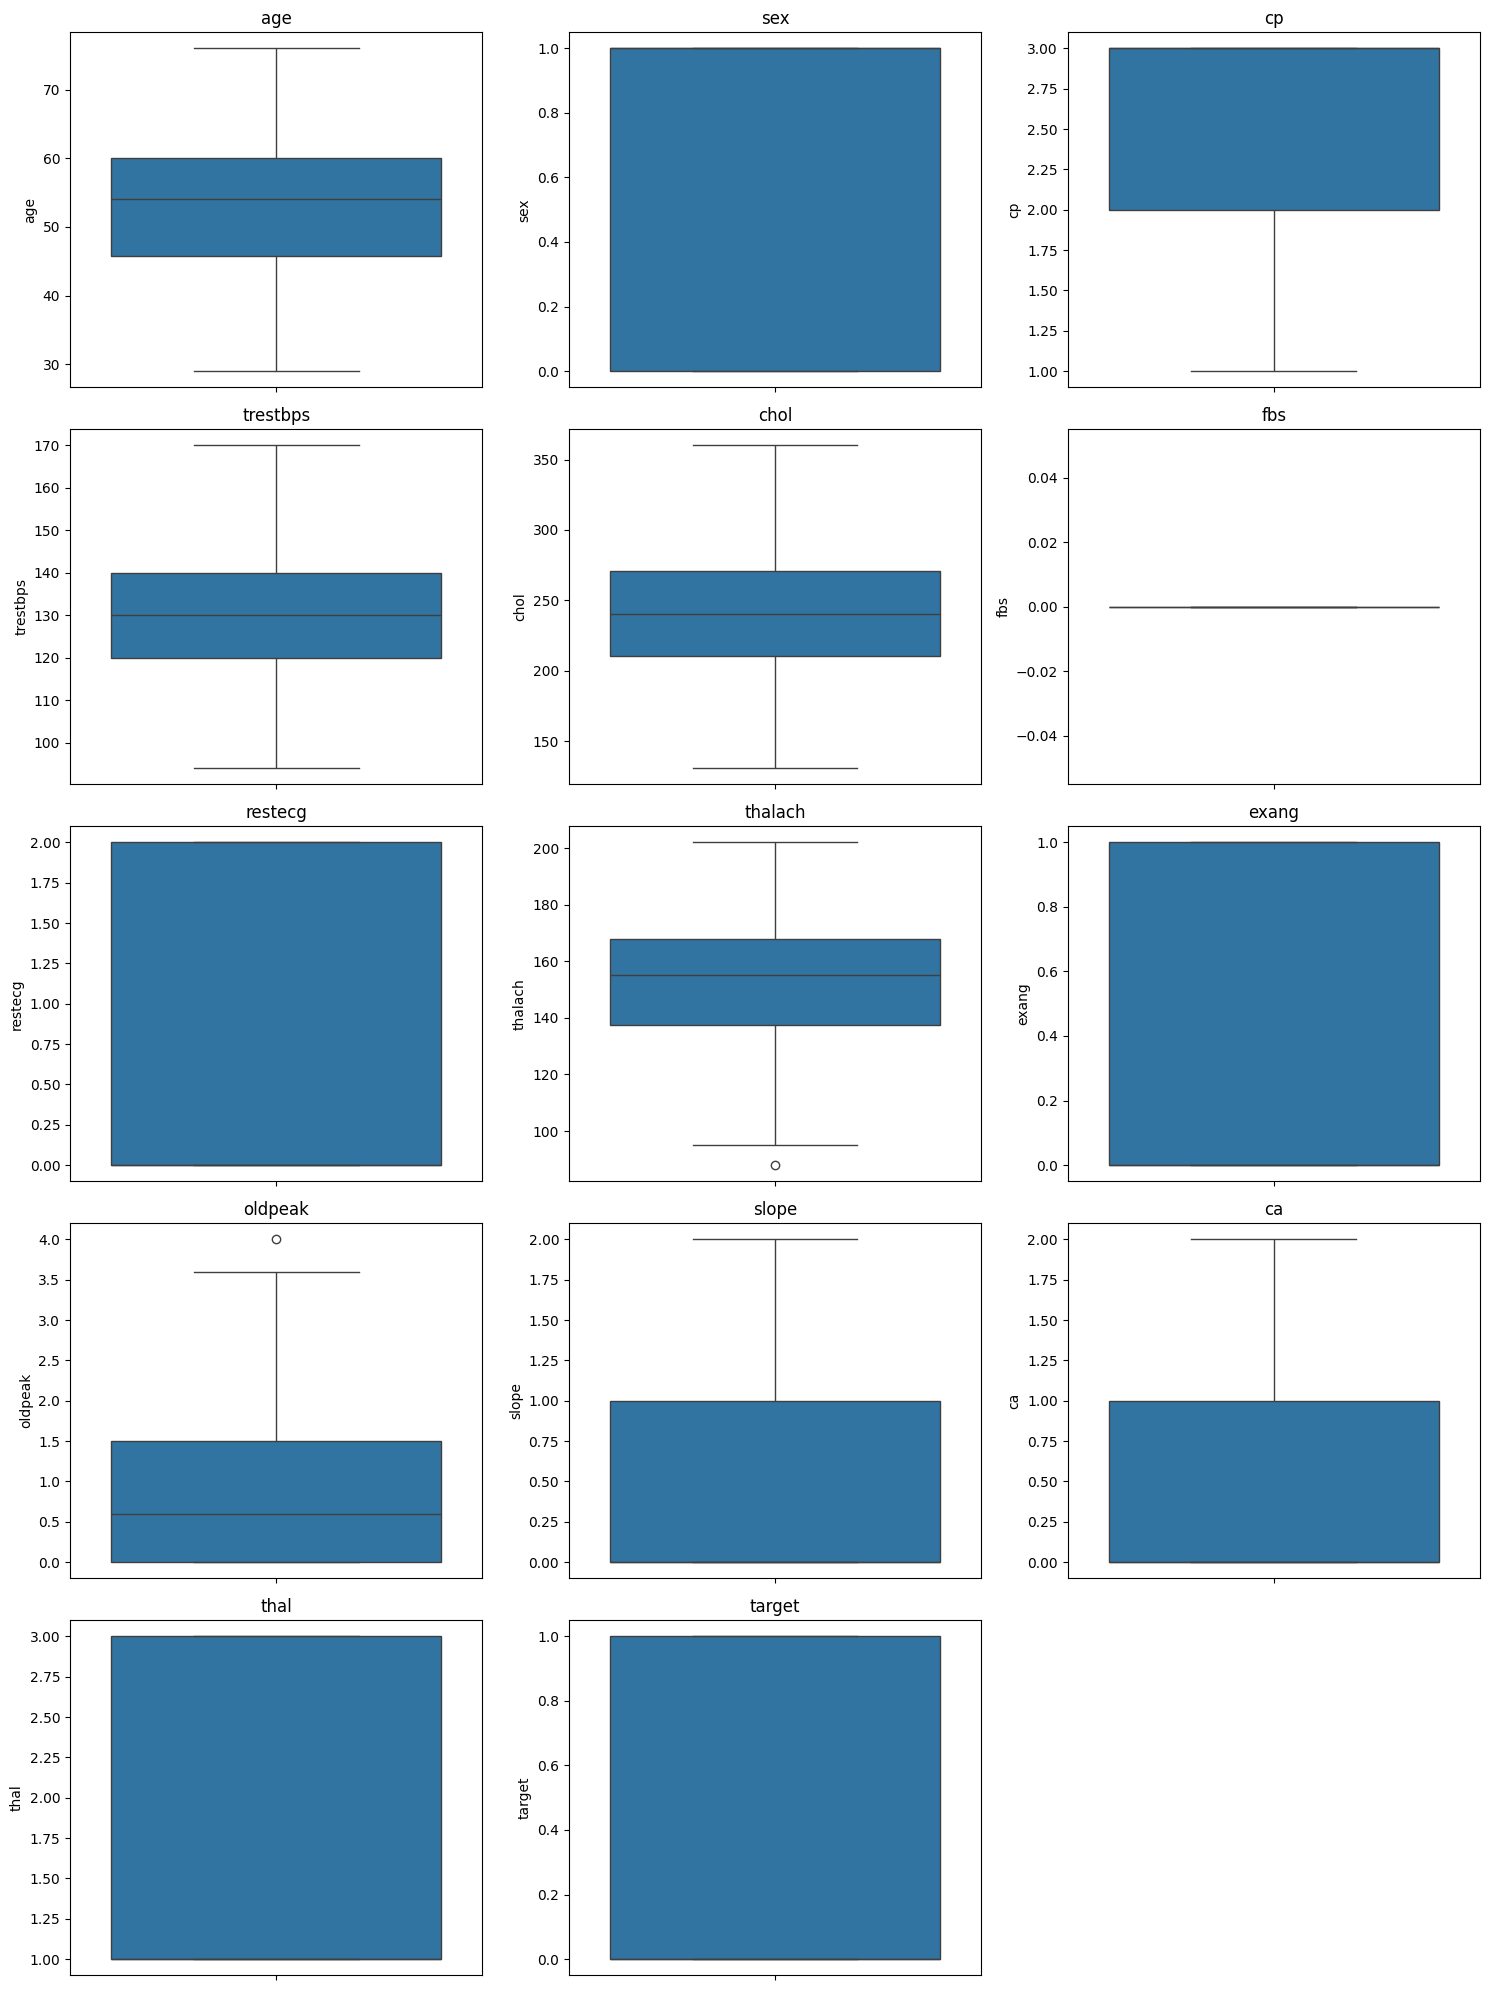

In [23]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

n = len(numeric_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


# Categorical Feature Distribution

If categorical columns exist:

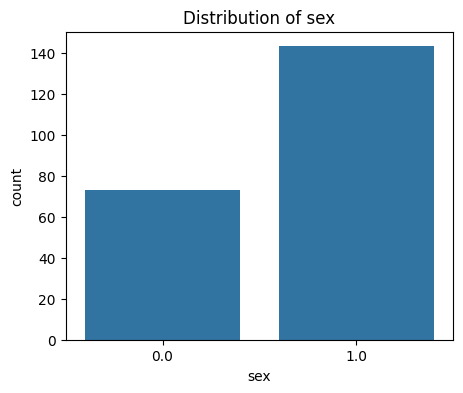

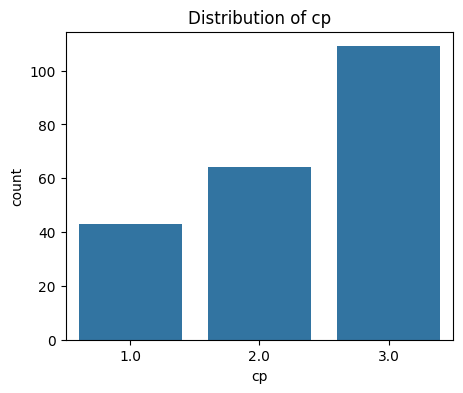

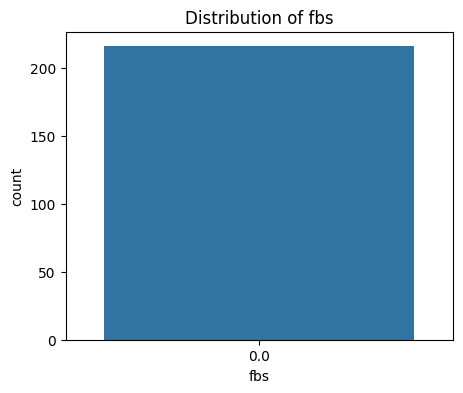

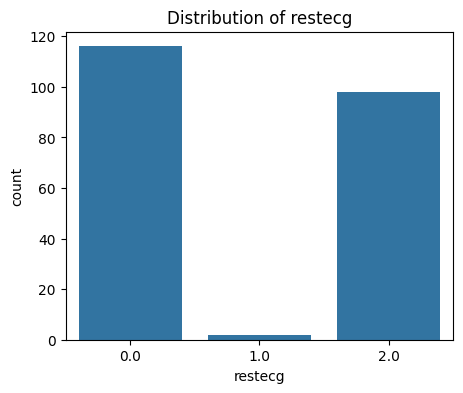

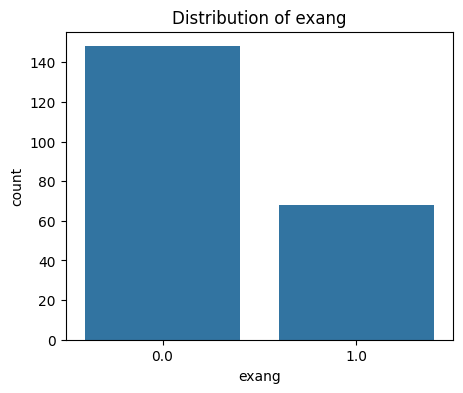

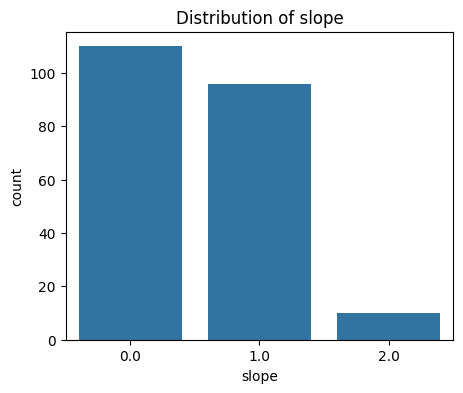

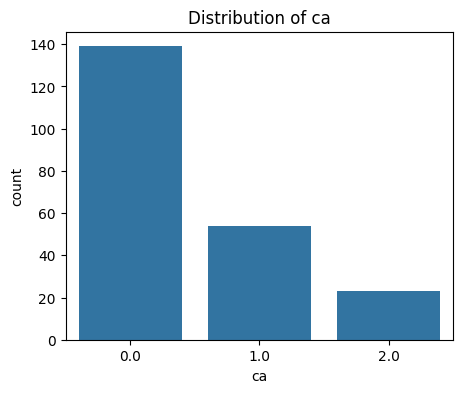

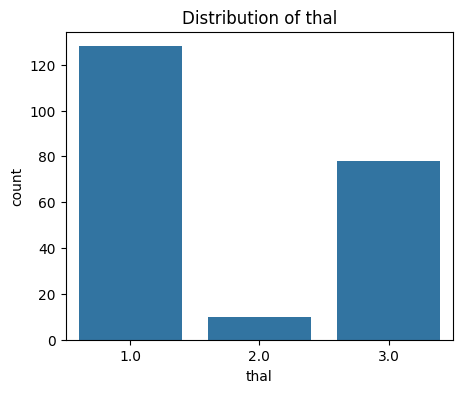

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define categorical columns manually
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 
                    'exang', 'slope', 'ca', 'thal']

for col in categorical_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


# Feature vs Target Analysis

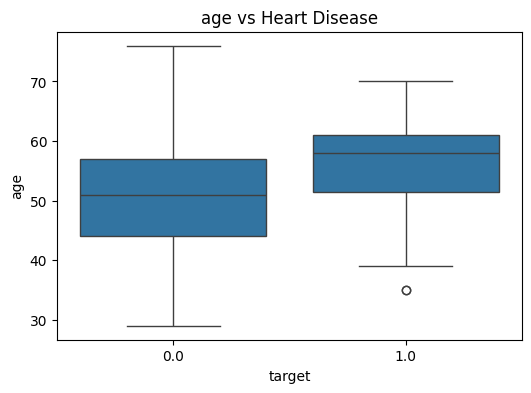

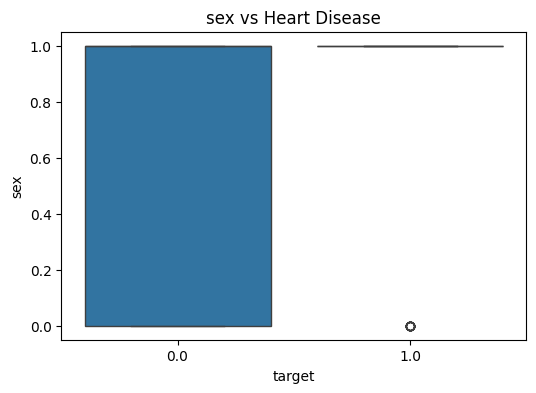

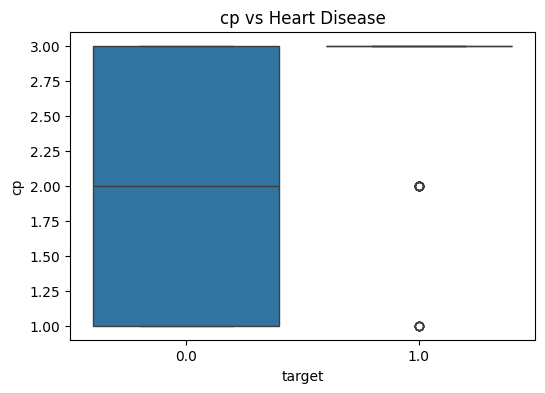

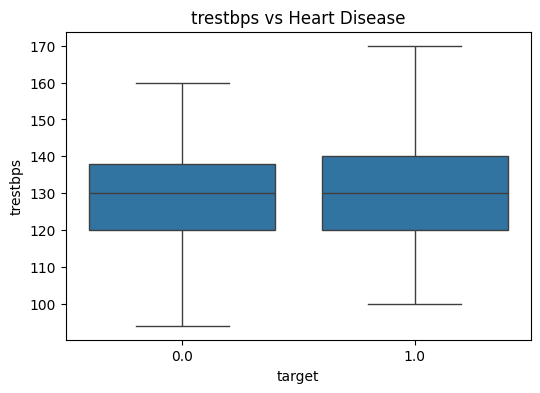

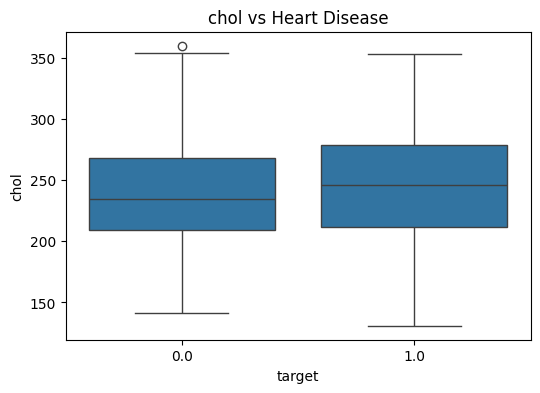

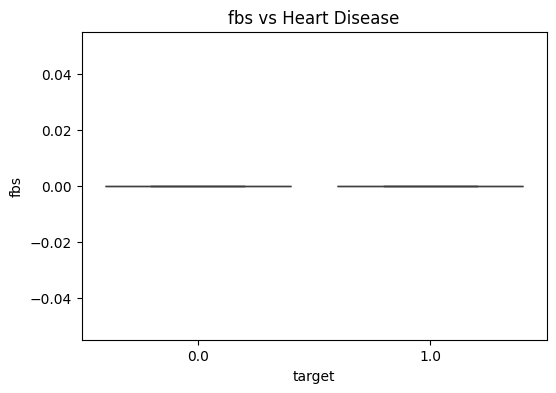

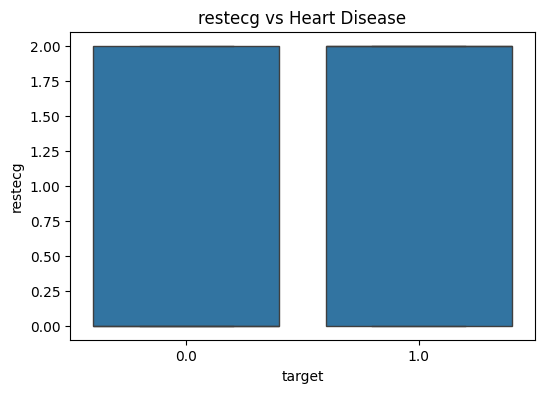

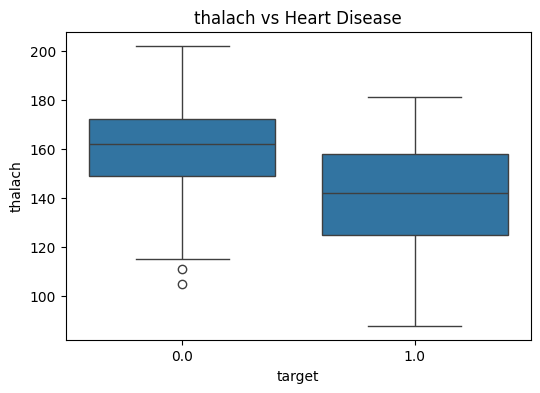

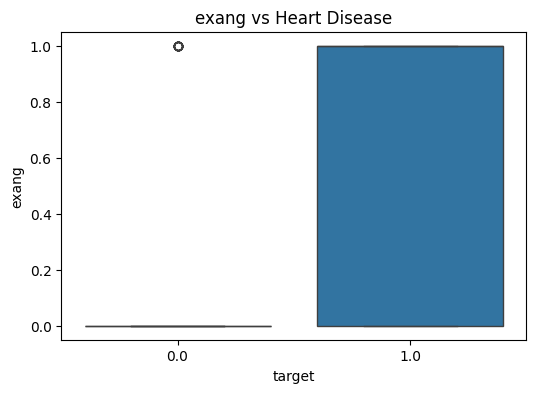

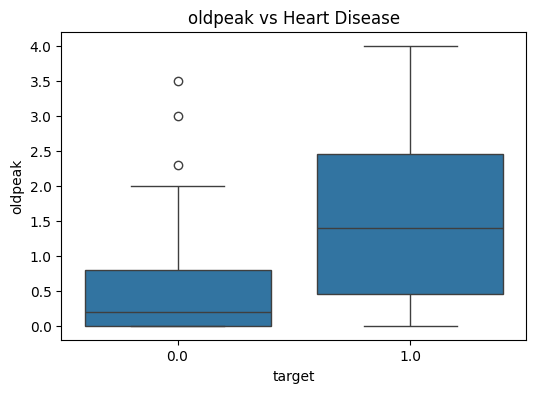

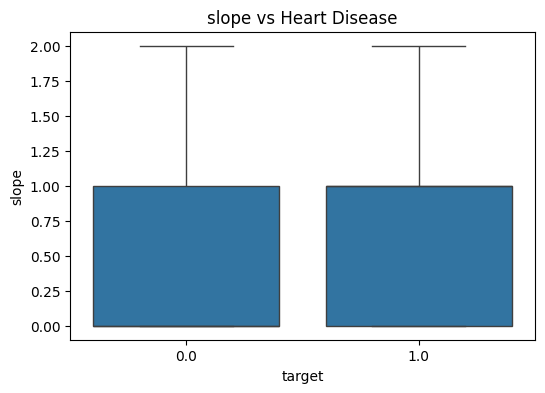

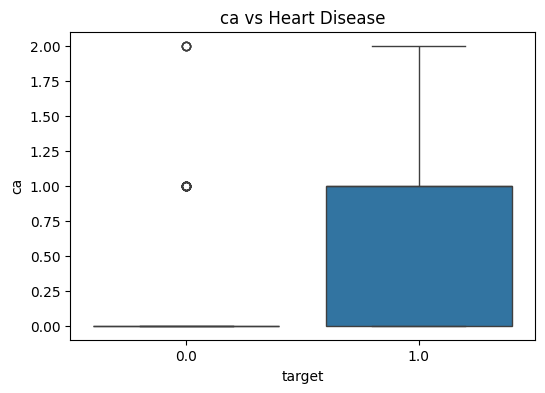

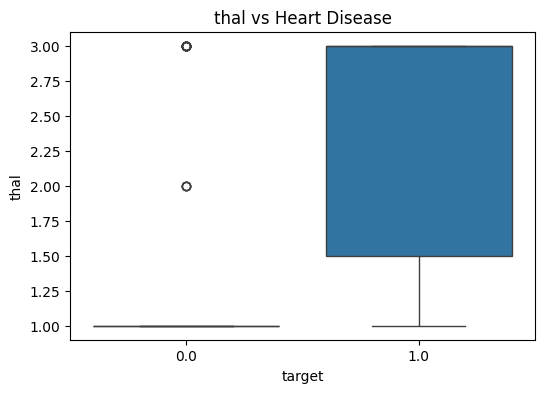

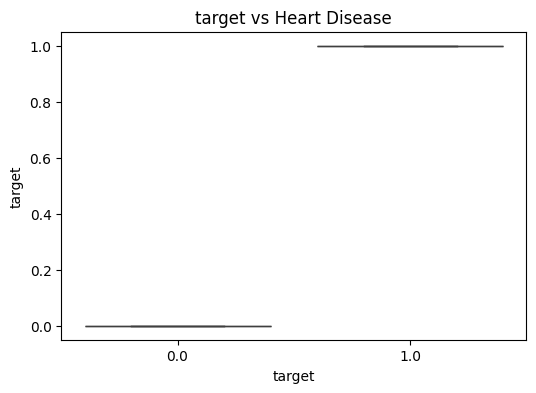

In [25]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()


# Categorical vs Target

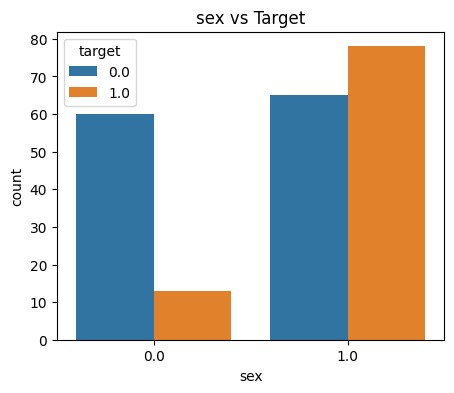

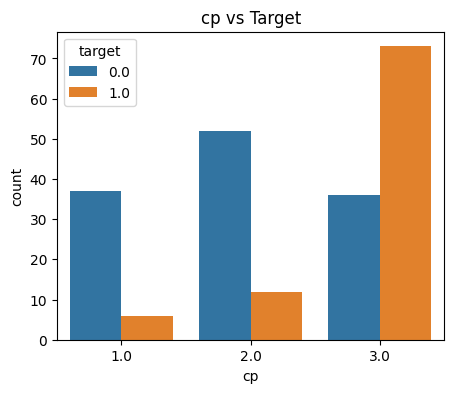

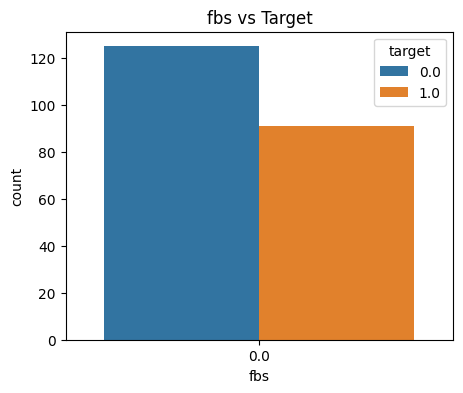

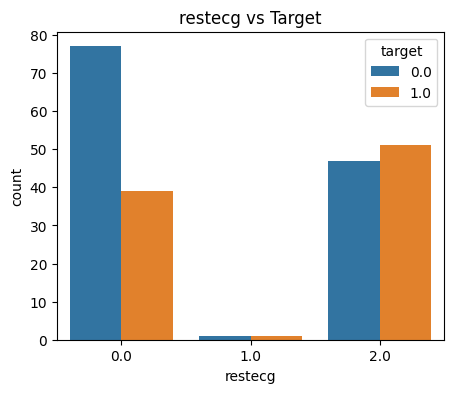

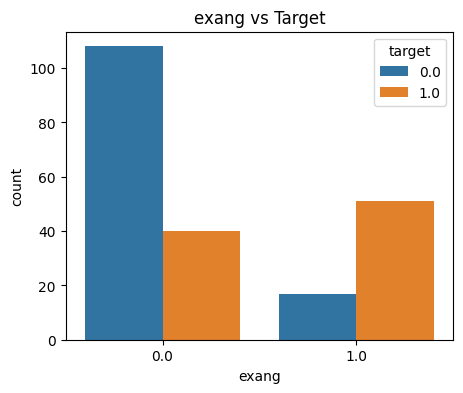

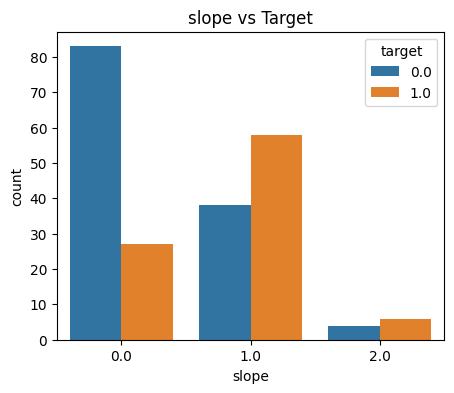

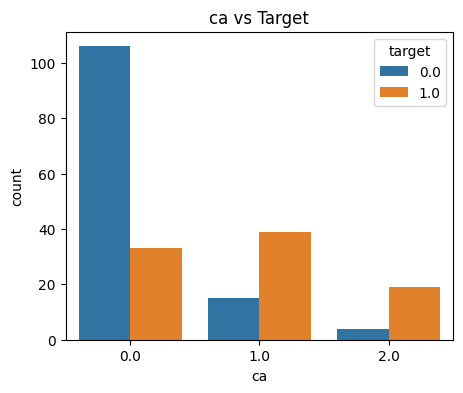

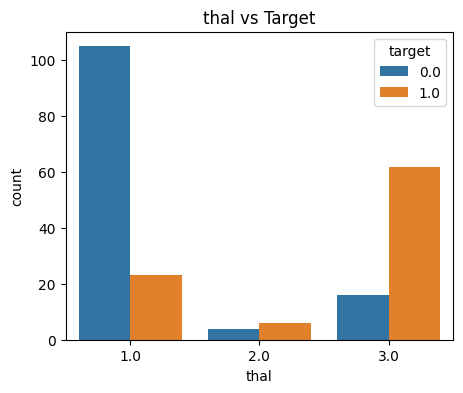

In [26]:
for col in categorical_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df[col], hue=df['target'])
    plt.title(f"{col} vs Target")
    plt.show()


# Pairplot (Important Features Only)

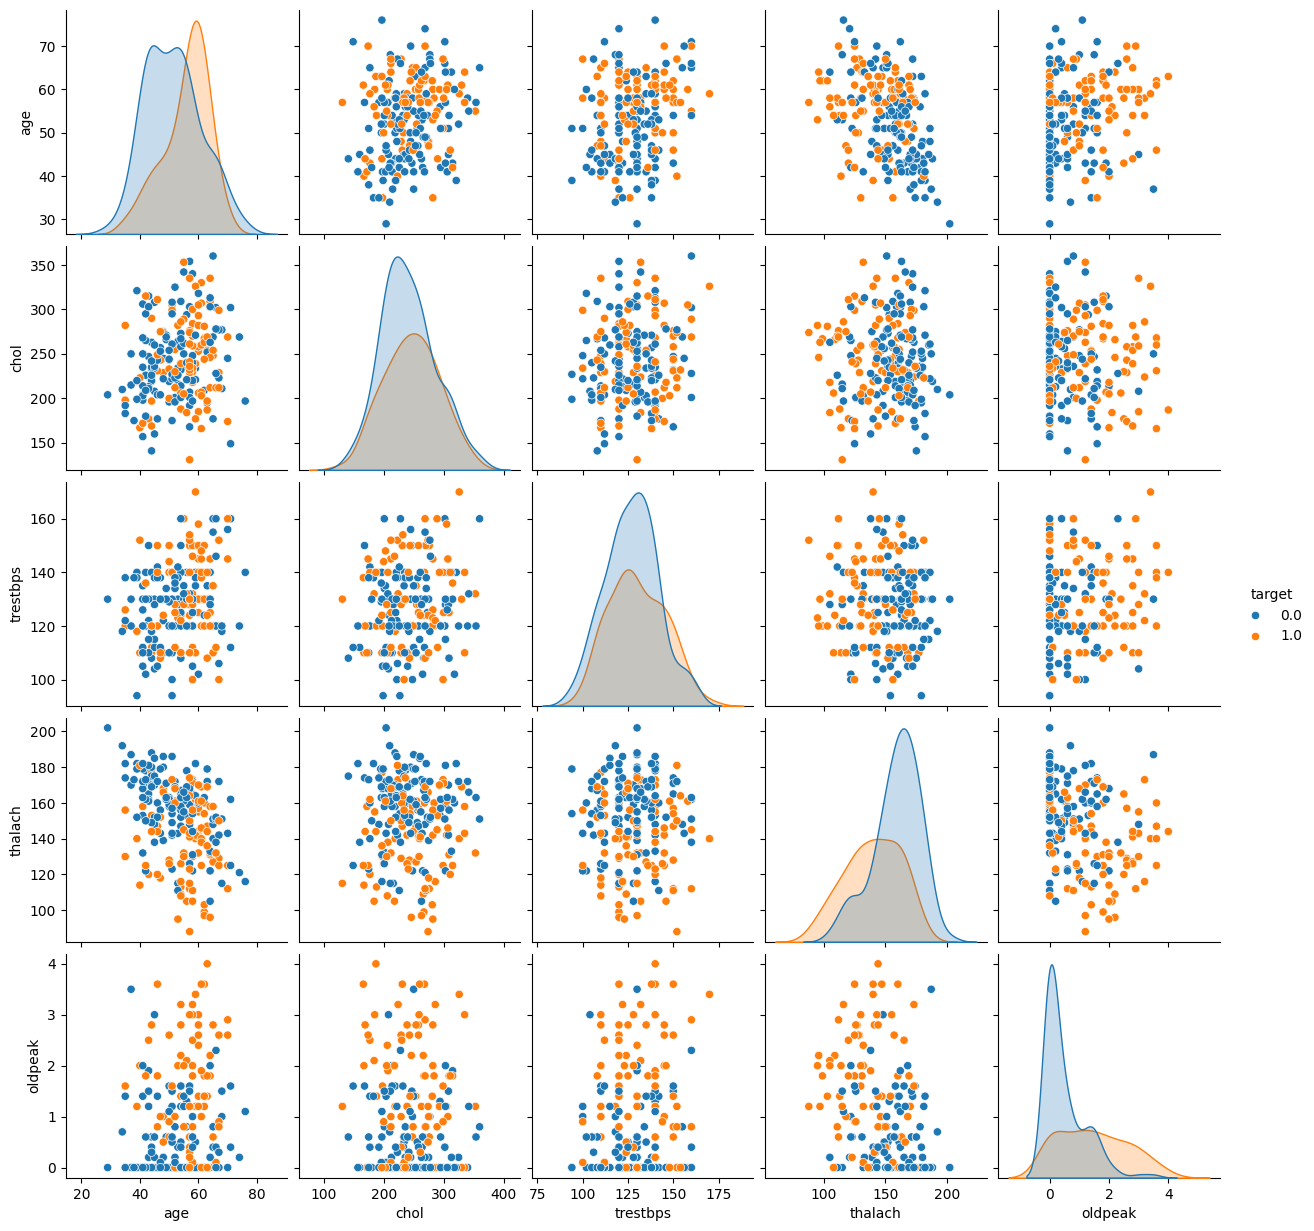

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

important_cols = ['age', 'chol', 'trestbps', 
                  'thalach', 'oldpeak', 'target']

sns.pairplot(df[important_cols], hue='target')
plt.show()


# Check Skewness

In [28]:
skewness = df[numeric_cols].skew()
print(skewness.sort_values(ascending=False))


ca          1.160869
oldpeak     1.047501
exang       0.803040
slope       0.556669
thal        0.478755
target      0.321023
chol        0.215869
restecg     0.168415
trestbps    0.162102
fbs         0.000000
age        -0.094870
thalach    -0.534232
cp         -0.596509
sex        -0.689923
dtype: float64


# Class-wise Mean Comparison

In [29]:
df.groupby('target').mean()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0.0,51.360000,0.520000,1.992000,126.920000,241.056000,0.0,0.760000,158.848000,0.13600,0.488000,0.368000,0.184000,1.288000
1.0,55.846154,0.857143,2.736264,130.131868,246.307692,0.0,1.131868,139.593407,0.56044,1.464835,0.769231,0.846154,2.428571


# Categorical Feature Distribution

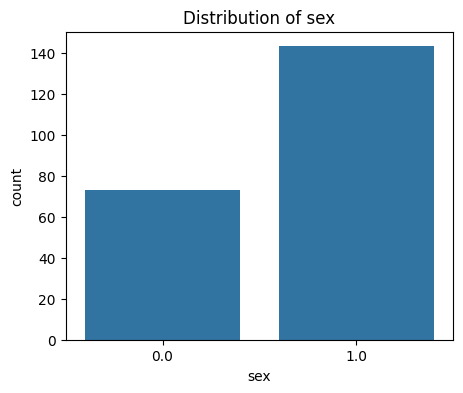

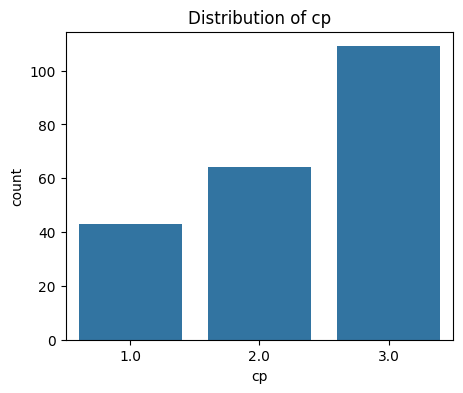

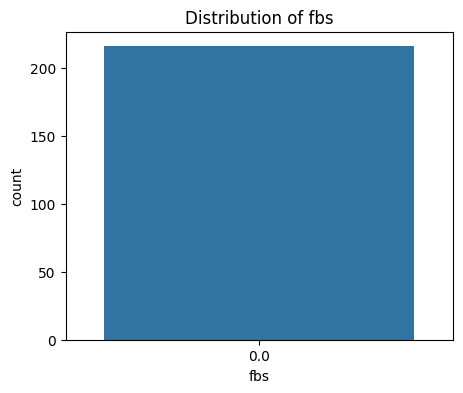

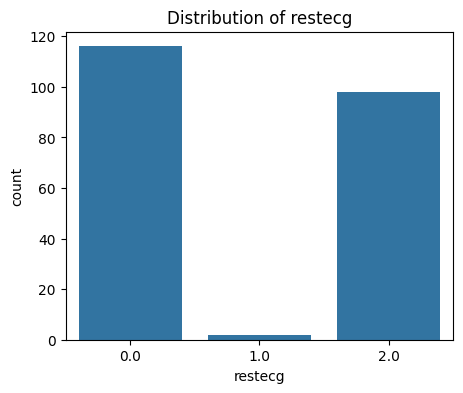

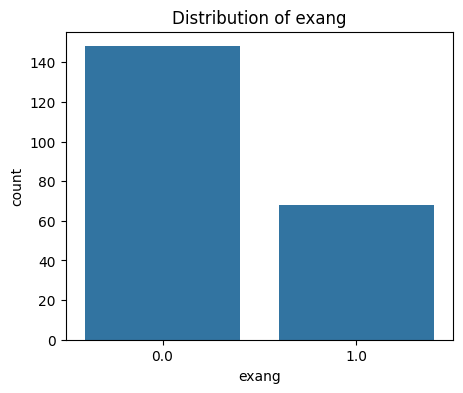

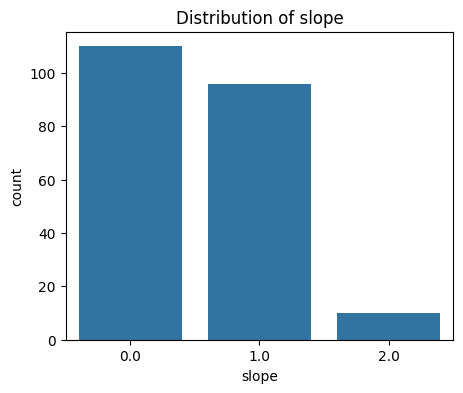

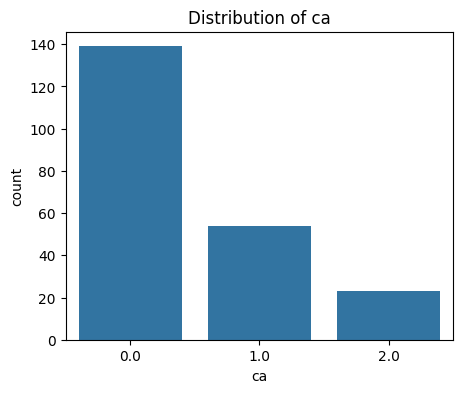

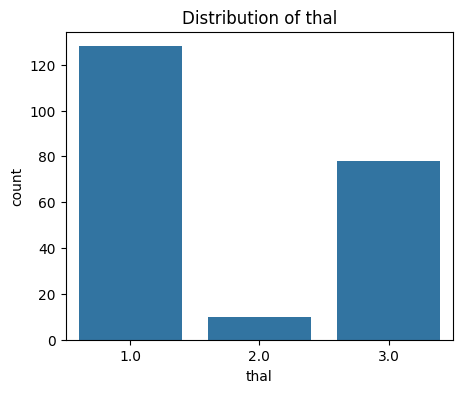

In [30]:
for col in categorical_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


In [31]:
pd.crosstab(df['target'], df['sex'])



sex,0.0,1.0
target,,
0.0,60,65
1.0,13,78


In [32]:
df['sex'].unique()


array([1., 0.])

# Feature Engineering